# Student Math Score Predictor
## Linear Regression Summative — Multivariate Analysis

**Mission:** Build a regression model to predict a student’s math score using academic and socioeconomic features in order to help educators identify students who may need additional academic support.

**Dataset:** `StudentsPerformance.csv` — 1,000 student records with 8 variables, sourced from [Kaggle: Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams).

**Problem:** Predict the continuous variable `math score` using multiple input features through regression analysis.

**Target Variable:** `math score` (continuous, 0–100)

**Predictor Features:** `gender`, `parental level of education`, `lunch`, `test preparation course`, `reading score`, `writing score`

---

---
## 1. Imports & Data Loading


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

df = pd.read_csv('StudentsPerformance.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## 2. Exploratory Data Analysis (EDA)


In [25]:
print('=== Basic Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe()

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB

=== Descriptive Statistics ===


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [26]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
                             Missing Count  Missing %
gender                                   0        0.0
race/ethnicity                           0        0.0
parental level of education              0        0.0
lunch                                    0        0.0
test preparation course                  0        0.0
math score                               0        0.0
reading score                            0        0.0
writing score                            0        0.0

Total missing values: 0


---
## 3. Visualization 1 — Correlation Heatmap

**Interpretation:** The heatmap reveals strong positive correlations between all three score variables. `reading score` (r ≈ 0.82) and `writing score` (r ≈ 0.80) are highly correlated with `math score`, confirming them as the most powerful predictors. This makes intuitive sense — students who perform well in reading and writing tend to also perform well in math.


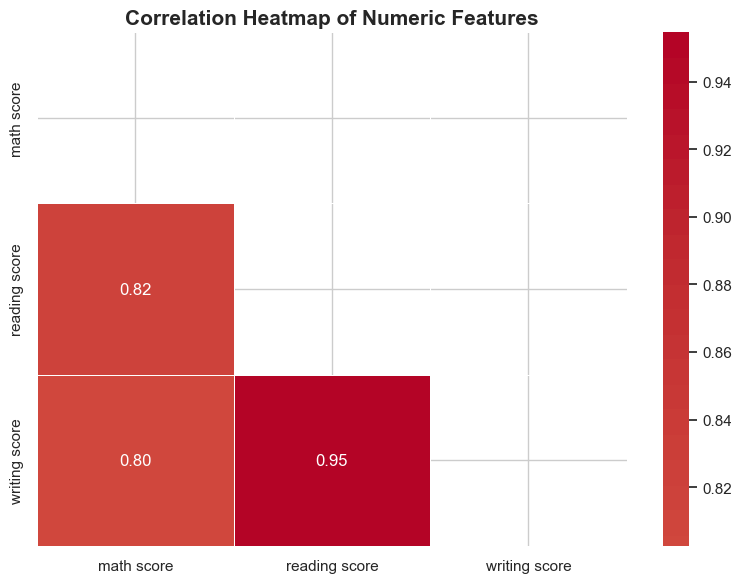


Correlation with math score:
math score       1.000000
reading score    0.817580
writing score    0.802642
Name: math score, dtype: float64


In [27]:
# Compute correlation on numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    mask=mask,
    linewidths=0.5,
    annot_kws={'size': 12}
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with math score:')
print(corr_matrix['math score'].sort_values(ascending=False))

---
## 4. Visualization 2 — Feature Distributions & Scatter Plots

**Interpretation:** The score distributions are approximately normal with slight left skew, indicating most students score in the 55–80 range. The scatter plots of `reading score` and `writing score` vs `math score` show clear positive linear trends, validating their use as strong predictors. The categorical box plots reveal that `lunch type` and `test preparation` have noticeable effects on math performance.


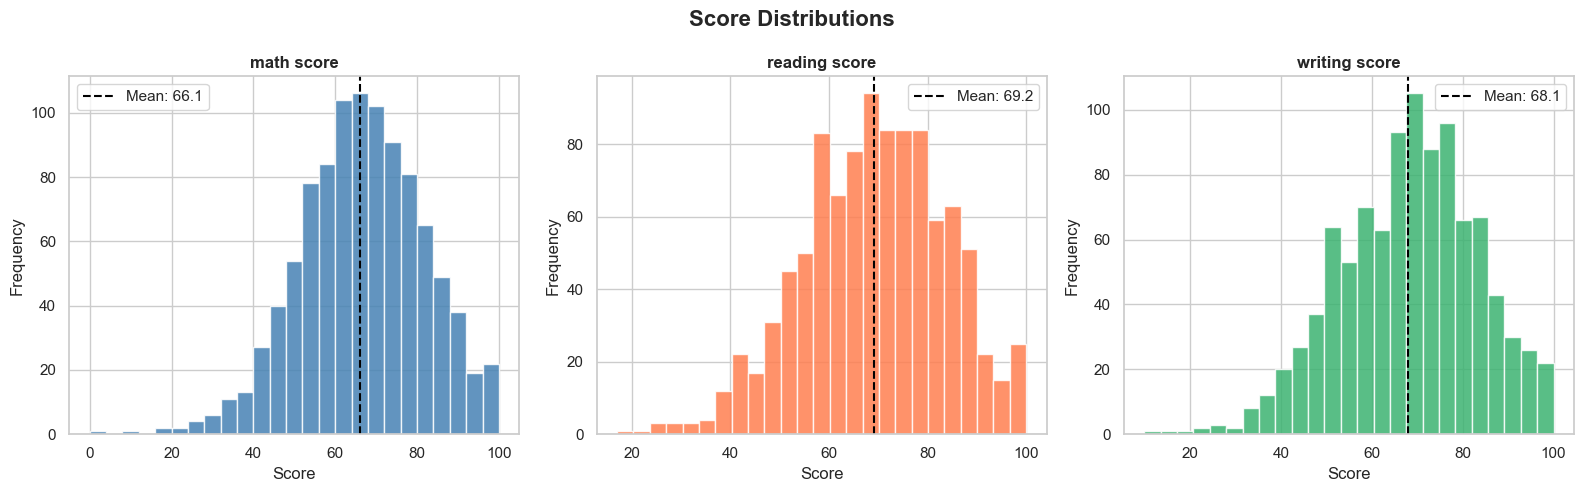

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score Distributions', fontsize=16, fontweight='bold')

score_cols = ['math score', 'reading score', 'writing score']
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col].dropna(), bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

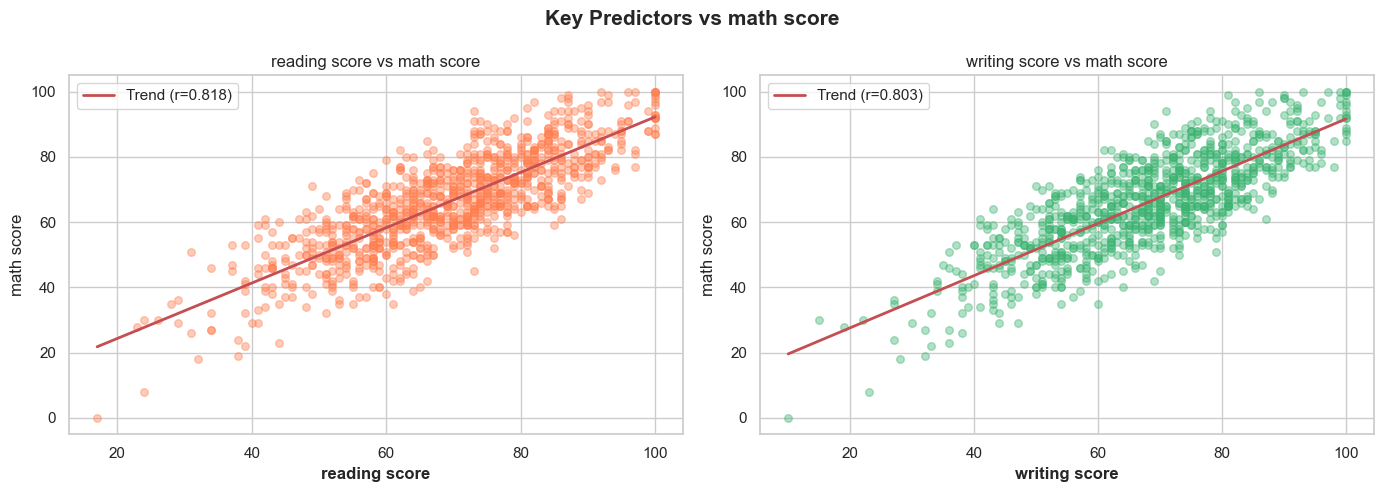

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Key Predictors vs math score', fontsize=15, fontweight='bold')

scatter_cols = ['reading score', 'writing score']
colors = ['coral', 'mediumseagreen']

for ax, col, color in zip(axes, scatter_cols, colors):
    subset = df[[col, 'math score']].dropna()
    ax.scatter(subset[col], subset['math score'], alpha=0.4, color=color, s=30)
    # Add trend line
    z = np.polyfit(subset[col], subset['math score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend (r={subset[col].corr(subset["math score"]):.3f})')
    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel('math score')
    ax.set_title(f'{col} vs math score')
    ax.legend()

plt.tight_layout()
plt.show()

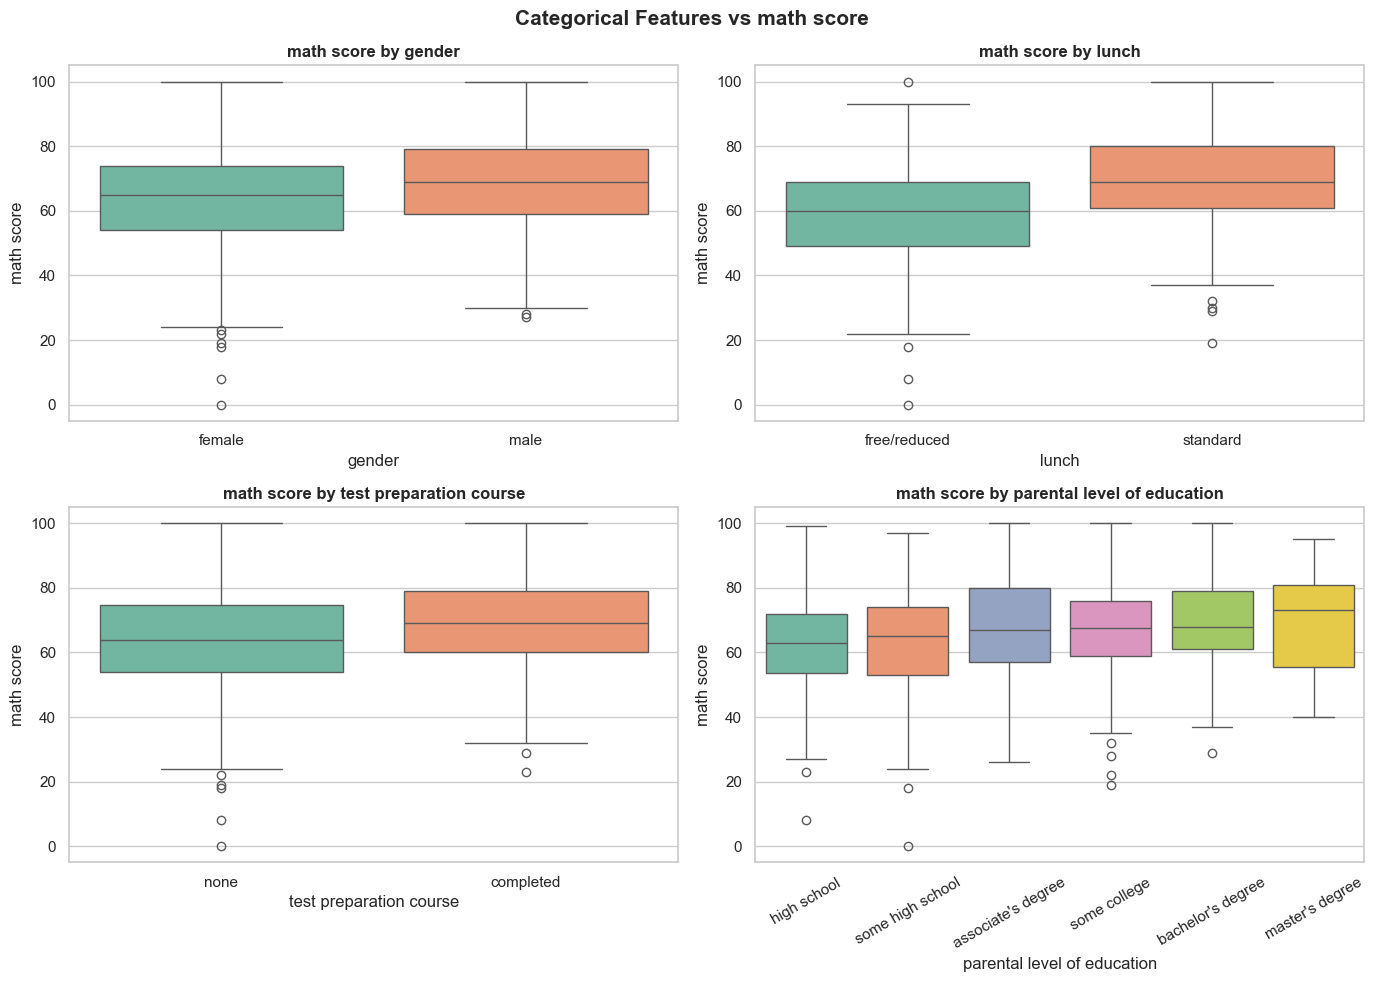

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Features vs math score', fontsize=15, fontweight='bold')

cat_cols = ['gender', 'lunch', 'test preparation course', 'parental level of education']

for ax, col in zip(axes.flatten(), cat_cols):
    order = df.groupby(col)['math score'].median().sort_values().index
    sns.boxplot(x=col, y='math score', data=df, ax=ax, order=order, palette='Set2')
    ax.set_title(f'math score by {col}', fontweight='bold')
    if col == 'parental level of education':
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

Steps:
1. Drop `race/ethnicity` — not included in our predictor feature set
2. Encode categorical variables to numeric:
   - `gender`: binary (female=0, male=1)
   - `lunch`: binary (free/reduced=0, standard=1)
   - `test preparation course`: binary (none=0, completed=1)
   - `parental level of education`: ordinal encoding (some high school=0 → master's degree=5)
3. Verify all features are numeric with no missing values

**Interpretation:** Ordinal encoding is used for `parental level of education` because there is a natural ordering from less to more education. Binary encoding is appropriate for the two-category features. `race/ethnicity` is dropped as it is not part of our selected predictor set.


In [31]:
df_clean = df.copy()

# 1. Drop columns not in our predictor set
df_clean.drop(columns=['race/ethnicity'], inplace=True)
print(f'After dropping race/ethnicity: {df_clean.shape}')

# 2. Encode categorical columns
# gender: binary
df_clean['gender'] = df_clean['gender'].map({'female': 0, 'male': 1})

# lunch: binary
df_clean['lunch'] = df_clean['lunch'].map({'free/reduced': 0, 'standard': 1})

# test preparation course: binary
df_clean['test preparation course'] = df_clean['test preparation course'].map({'none': 0, 'completed': 1})

# parental level of education: ordinal encoding
edu_order = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
df_clean['parental level of education'] = df_clean['parental level of education'].map(edu_order)

print('\nEncoding applied. Data types:')
print(df_clean.dtypes)
print('\nSample after encoding:')
df_clean.head()

After dropping race/ethnicity: (1000, 7)

Encoding applied. Data types:
gender                         int64
parental level of education    int64
lunch                          int64
test preparation course        int64
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Sample after encoding:


,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,4,1,0,72,72,74
1,0,2,1,1,69,90,88
2,0,5,1,0,90,95,93
3,1,3,0,0,47,57,44
4,1,2,1,0,76,78,75


In [32]:
# 3. Verify all features are numeric and no missing values
print('=== All columns numeric check ===')
print(df_clean.dtypes)
non_numeric = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'\nNon-numeric columns remaining: {non_numeric if non_numeric else "None"}')
print(f'Total missing values: {df_clean.isnull().sum().sum()}')

=== All columns numeric check ===
gender                         int64
parental level of education    int64
lunch                          int64
test preparation course        int64
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Non-numeric columns remaining: None
Total missing values: 0


---
## 6. Data Standardization


In [33]:
# Separate features and target
X = df_clean.drop(columns=['math score'])
y = df_clean['math score'].values

print(f'Features: {list(X.columns)}')
print(f'Target: math score')
print(f'X shape: {X.shape}, y shape: {y.shape}')

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('\n=== Before Standardization (sample stats) ===')
print(X.describe().loc[['mean', 'std']].round(2))

print('\n=== After Standardization (sample stats) ===')
print(X_scaled.describe().loc[['mean', 'std']].round(4))

Features: ['gender', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']
Target: math score
X shape: (1000, 6), y shape: (1000,)

=== Before Standardization (sample stats) ===
      gender  parental level of education  lunch  test preparation course  \
mean    0.48                         2.08   0.64                     0.36   
std     0.50                         1.46   0.48                     0.48   

      reading score  writing score  
mean          69.17          68.05  
std           14.60          15.20  

=== After Standardization (sample stats) ===
      gender  parental level of education   lunch  test preparation course  \
mean  0.0000                      -0.0000 -0.0000                  -0.0000   
std   1.0005                       1.0005  1.0005                   1.0005   

      reading score  writing score  
mean         0.0000        -0.0000  
std          1.0005         1.0005  


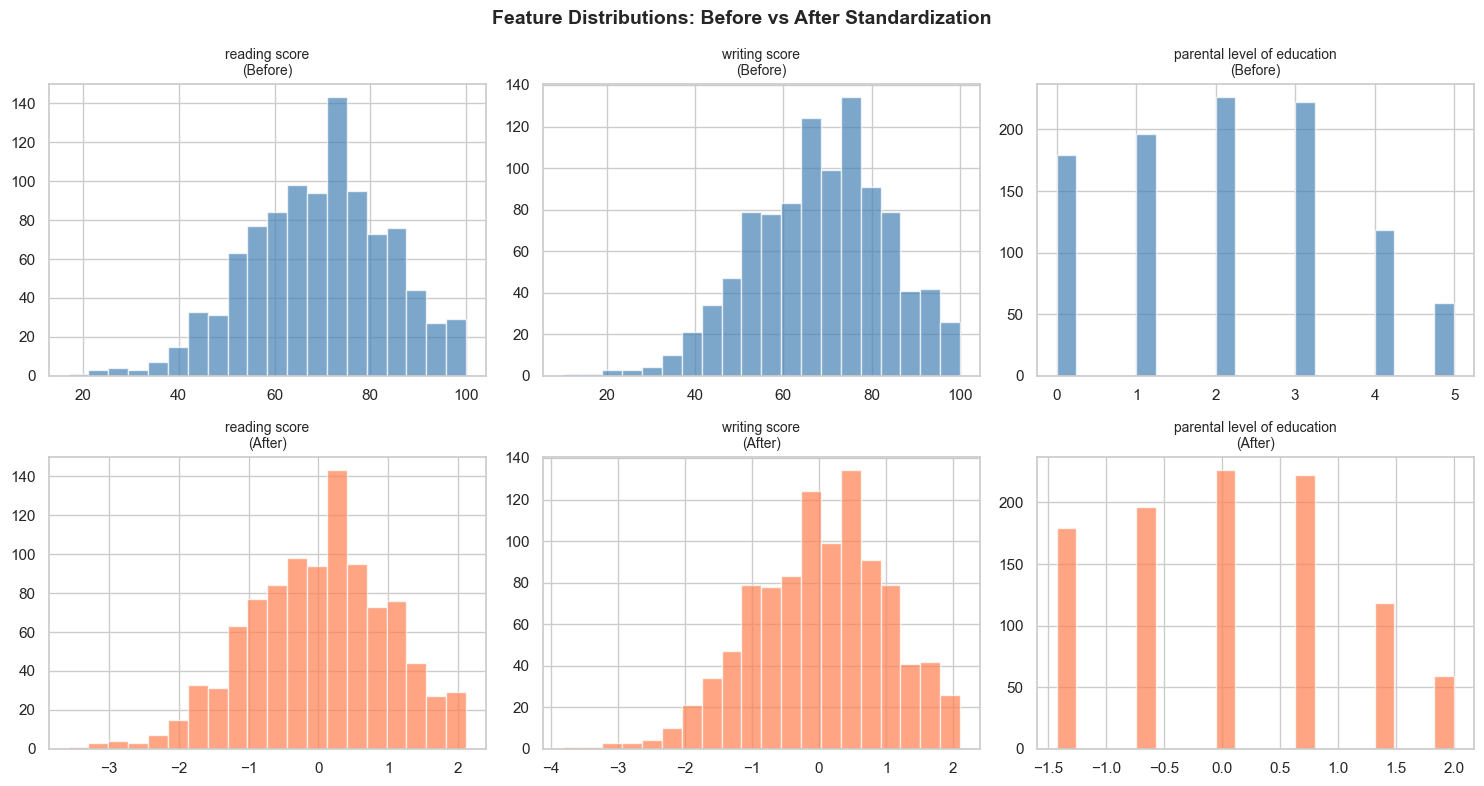

In [34]:
# Visual comparison for key numeric features
vis_cols = ['reading score', 'writing score', 'parental level of education']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions: Before vs After Standardization', fontsize=14, fontweight='bold')

for i, col in enumerate(vis_cols):
    axes[0, i].hist(X[col], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Before)', fontsize=10)
    axes[1, i].hist(X_scaled[col], bins=20, color='coral', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(After)', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Train/Test Split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')

Training set: 800 samples
Test set:     200 samples
Features:     6


---
## 8. Linear Regression with Gradient Descent (SGDRegressor)

We use `SGDRegressor` to implement gradient descent and track the loss per epoch, then compare with the closed-form `LinearRegression`.


In [36]:
# --- SGDRegressor: Gradient Descent with loss tracking ---
n_epochs = 200
train_losses = []
test_losses = []

sgd_model = SGDRegressor(
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None
)

X_train_arr = X_train.values
X_test_arr  = X_test.values

for epoch in range(n_epochs):
    sgd_model.fit(X_train_arr, y_train)
    y_pred_train = sgd_model.predict(X_train_arr)
    y_pred_test  = sgd_model.predict(X_test_arr)
    train_losses.append(mean_squared_error(y_train, y_pred_train))
    test_losses.append(mean_squared_error(y_test, y_pred_test))

print(f'SGD Final Train MSE: {train_losses[-1]:.4f}')
print(f'SGD Final Test  MSE: {test_losses[-1]:.4f}')
print(f'SGD Train R²: {r2_score(y_train, sgd_model.predict(X_train_arr)):.4f}')
print(f'SGD Test  R²: {r2_score(y_test, sgd_model.predict(X_test_arr)):.4f}')

SGD Final Train MSE: 32.5975
SGD Final Test  MSE: 29.4025
SGD Train R²: 0.8554
SGD Test  R²: 0.8792


In [37]:
# --- Closed-form Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_arr, y_train)

y_pred_lr_train = lr_model.predict(X_train_arr)
y_pred_lr_test  = lr_model.predict(X_test_arr)

lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse  = mean_squared_error(y_test,  y_pred_lr_test)
lr_train_r2  = r2_score(y_train, y_pred_lr_train)
lr_test_r2   = r2_score(y_test,  y_pred_lr_test)
lr_test_rmse = np.sqrt(lr_test_mse)

print(f'LinearRegression Train MSE: {lr_train_mse:.4f} | Test MSE: {lr_test_mse:.4f}')
print(f'LinearRegression Train R²:  {lr_train_r2:.4f}  | Test R²:  {lr_test_r2:.4f}')
print(f'LinearRegression Test RMSE: {lr_test_rmse:.4f}')

print('\nFeature Coefficients:')
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

LinearRegression Train MSE: 31.9536 | Test MSE: 28.8318
LinearRegression Train R²:  0.8583  | Test R²:  0.8815
LinearRegression Test RMSE: 5.3695

Feature Coefficients:
                    Feature  Coefficient
              writing score    10.263537
                     gender     6.542227
              reading score     4.259594
                      lunch     1.729169
parental level of education    -0.536699
    test preparation course    -1.413282


---
## 9. Decision Tree Regressor


In [38]:
# Grid search for best max_depth
dt_params = {'max_depth': [3, 5, 7, 10, None]}
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
dt_grid.fit(X_train_arr, y_train)

dt_model = dt_grid.best_estimator_
print(f'Best max_depth: {dt_grid.best_params_}')

y_pred_dt_train = dt_model.predict(X_train_arr)
y_pred_dt_test  = dt_model.predict(X_test_arr)

dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse  = mean_squared_error(y_test,  y_pred_dt_test)
dt_train_r2  = r2_score(y_train, y_pred_dt_train)
dt_test_r2   = r2_score(y_test,  y_pred_dt_test)
dt_test_rmse = np.sqrt(dt_test_mse)

print(f'Decision Tree Train MSE: {dt_train_mse:.4f} | Test MSE: {dt_test_mse:.4f}')
print(f'Decision Tree Train R²:  {dt_train_r2:.4f}  | Test R²:  {dt_test_r2:.4f}')
print(f'Decision Tree Test RMSE: {dt_test_rmse:.4f}')

Best max_depth: {'max_depth': 5}
Decision Tree Train MSE: 33.2136 | Test MSE: 39.2489
Decision Tree Train R²:  0.8527  | Test R²:  0.8387
Decision Tree Test RMSE: 6.2649


---
## 10. Random Forest Regressor


Best RF params: {'max_depth': 5, 'n_estimators': 200}
Random Forest Train MSE: 28.9432 | Test MSE: 34.9561
Random Forest Train R²:  0.8716  | Test R²:  0.8563
Random Forest Test RMSE: 5.9124


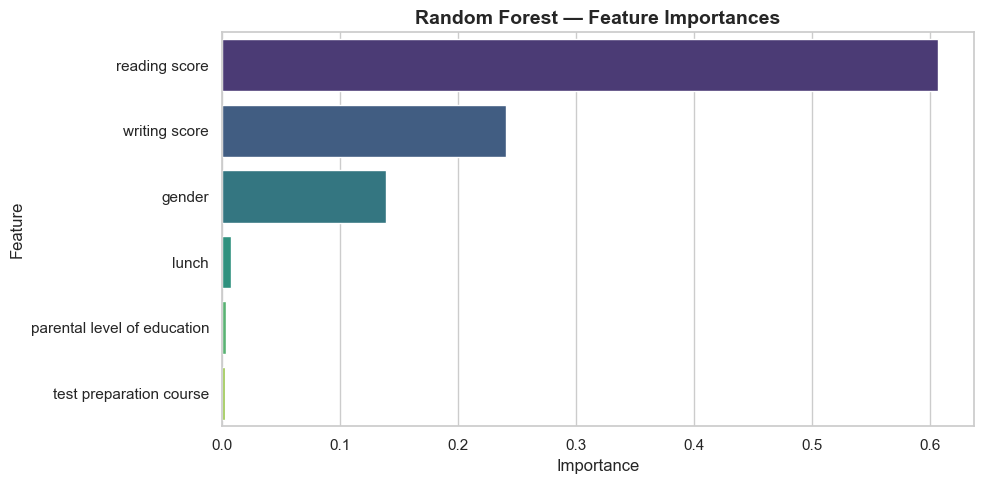

In [39]:
# Tune n_estimators and max_depth
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
rf_grid.fit(X_train_arr, y_train)

rf_model = rf_grid.best_estimator_
print(f'Best RF params: {rf_grid.best_params_}')

y_pred_rf_train = rf_model.predict(X_train_arr)
y_pred_rf_test  = rf_model.predict(X_test_arr)

rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse  = mean_squared_error(y_test,  y_pred_rf_test)
rf_train_r2  = r2_score(y_train, y_pred_rf_train)
rf_test_r2   = r2_score(y_test,  y_pred_rf_test)
rf_test_rmse = np.sqrt(rf_test_mse)

print(f'Random Forest Train MSE: {rf_train_mse:.4f} | Test MSE: {rf_test_mse:.4f}')
print(f'Random Forest Train R²:  {rf_train_r2:.4f}  | Test R²:  {rf_test_r2:.4f}')
print(f'Random Forest Test RMSE: {rf_test_rmse:.4f}')

# Feature importance
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Loss Curves (Train vs Test) — Gradient Descent


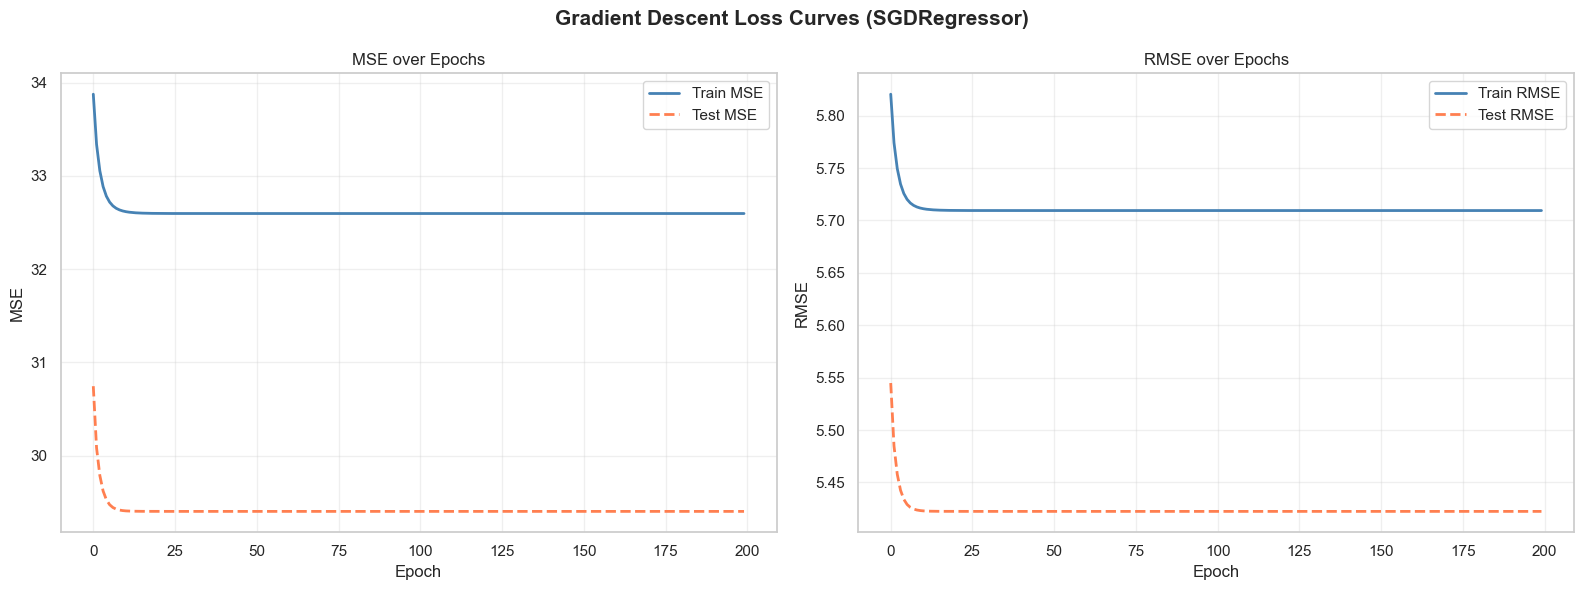

Converged Train RMSE: 5.7094
Converged Test  RMSE: 5.4224


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gradient Descent Loss Curves (SGDRegressor)', fontsize=15, fontweight='bold')

# MSE curves
axes[0].plot(train_losses, label='Train MSE', color='steelblue', linewidth=2)
axes[0].plot(test_losses,  label='Test MSE',  color='coral',     linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE curves
train_rmse_curve = np.sqrt(train_losses)
test_rmse_curve  = np.sqrt(test_losses)
axes[1].plot(train_rmse_curve, label='Train RMSE', color='steelblue', linewidth=2)
axes[1].plot(test_rmse_curve,  label='Test RMSE',  color='coral',     linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Converged Train RMSE: {train_rmse_curve[-1]:.4f}')
print(f'Converged Test  RMSE: {test_rmse_curve[-1]:.4f}')

---
## 12. Scatter Plot — Before & After (with Regression Line)

Using the most correlated feature (`reading score`) vs `math score` to visualize the fitted regression line.


Most correlated feature: reading score (r=0.818)


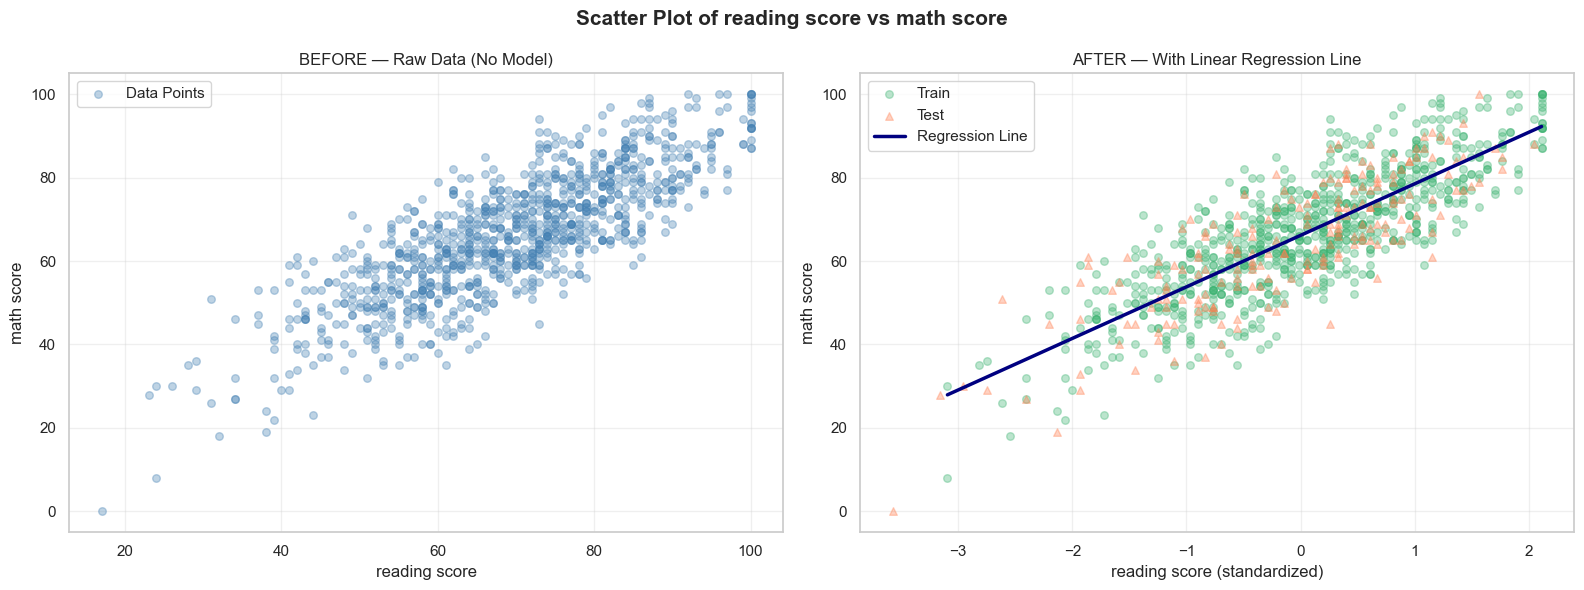

In [41]:
# Find the most correlated feature with math score
corr_with_target = X.corrwith(pd.Series(y, name='math score')).abs()
best_feature = corr_with_target.idxmax()
print(f'Most correlated feature: {best_feature} (r={corr_with_target[best_feature]:.3f})')

best_feat_idx = list(X_train.columns).index(best_feature)

# Use original (unscaled) values for the before plot
x_orig_full = X[best_feature].values

# Use scaled values for the after plot
x_scaled_train = X_train_arr[:, best_feat_idx]
x_scaled_test  = X_test_arr[:, best_feat_idx]

# Fit a simple LR on 1 feature for visualization
lr_1d = LinearRegression()
lr_1d.fit(x_scaled_train.reshape(-1, 1), y_train)
x_line = np.linspace(x_scaled_train.min(), x_scaled_train.max(), 200).reshape(-1, 1)
y_line = lr_1d.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Scatter Plot of {best_feature} vs math score', fontsize=15, fontweight='bold')

# BEFORE: raw data, no regression line
axes[0].scatter(x_orig_full, y, alpha=0.35, color='steelblue', s=30, label='Data Points')
axes[0].set_xlabel(best_feature)
axes[0].set_ylabel('math score')
axes[0].set_title('BEFORE — Raw Data (No Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AFTER: standardized data + regression line
axes[1].scatter(x_scaled_train, y_train, alpha=0.35, color='mediumseagreen', s=30, label='Train')
axes[1].scatter(x_scaled_test,  y_test,  alpha=0.35, color='coral',          s=30, label='Test', marker='^')
axes[1].plot(x_line, y_line, color='navy', linewidth=2.5, label='Regression Line')
axes[1].set_xlabel(f'{best_feature} (standardized)')
axes[1].set_ylabel('math score')
axes[1].set_title('AFTER — With Linear Regression Line')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 13. Model Comparison & Best Model Selection


=== Model Comparison ===
                   Train MSE  Test MSE  Test RMSE  Train R²  Test R²
Model                                                               
Linear Regression    31.9536   28.8318     5.3695    0.8583   0.8815
Decision Tree        33.2136   39.2489     6.2649    0.8527   0.8387
Random Forest        28.9432   34.9561     5.9124    0.8716   0.8563


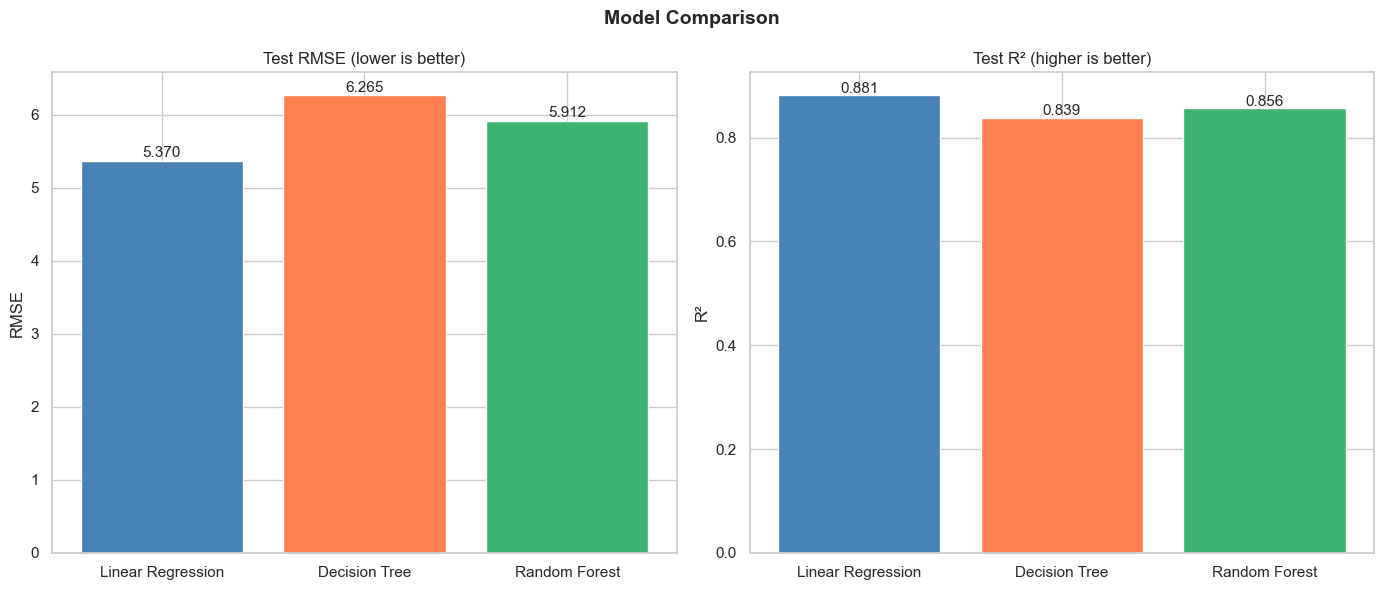


Best Model: Linear Regression (lowest Test MSE = 28.8318)


In [42]:
results = pd.DataFrame({
    'Model':      ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE':  [lr_train_mse,  dt_train_mse,  rf_train_mse],
    'Test MSE':   [lr_test_mse,   dt_test_mse,   rf_test_mse],
    'Test RMSE':  [lr_test_rmse,  dt_test_rmse,  rf_test_rmse],
    'Train R²':   [lr_train_r2,   dt_train_r2,   rf_train_r2],
    'Test R²':    [lr_test_r2,    dt_test_r2,    rf_test_r2],
})
results = results.set_index('Model').round(4)
print('=== Model Comparison ===')
print(results.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

models    = results.index.tolist()
test_rmse = results['Test RMSE'].values
test_r2   = results['Test R²'].values
colors    = ['steelblue', 'coral', 'mediumseagreen']

axes[0].bar(models, test_rmse, color=colors, edgecolor='white')
axes[0].set_title('Test RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
for bar, val in zip(axes[0].patches, test_rmse):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.3f}', ha='center', fontsize=11)

axes[1].bar(models, test_r2, color=colors, edgecolor='white')
axes[1].set_title('Test R² (higher is better)')
axes[1].set_ylabel('R²')
for bar, val in zip(axes[1].patches, test_r2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Identify best
best_idx = results['Test MSE'].idxmin()
print(f'\nBest Model: {best_idx} (lowest Test MSE = {results.loc[best_idx, "Test MSE"]:.4f})')

---
## 14. Save the Best Model


In [43]:
import os

model_map = {
    'Linear Regression': lr_model,
    'Decision Tree':      dt_model,
    'Random Forest':      rf_model
}

best_model = model_map[best_idx]

# Save model, scaler, and feature columns (needed for predictions)
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(list(X_train.columns), 'feature_columns.pkl')

assert os.path.exists('best_model.pkl'), 'Model file not found!'
print(f'Best model saved: best_model.pkl ({best_idx})')
print('Scaler saved: scaler.pkl')
print('Feature columns saved: feature_columns.pkl')

Best model saved: best_model.pkl (Linear Regression)
Scaler saved: scaler.pkl
Feature columns saved: feature_columns.pkl


---
## 15. Single Prediction — Using the Best Model

Demonstrates how to load the saved model and predict on a single data point from the test set.


In [44]:
# Load saved artifacts
loaded_model    = joblib.load('best_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')

# Take the first row of the test set
sample_index = 0
sample_scaled = X_test_arr[sample_index].reshape(1, -1)

# Make prediction
predicted_score = loaded_model.predict(sample_scaled)[0]
actual_score    = y_test[sample_index]

print('=== Single Data Point Prediction ===')
print(f'Features used:    {loaded_features}')
print(f'Feature values (scaled): {sample_scaled.flatten().round(4).tolist()}')
print(f'\nPredicted math score: {predicted_score:.2f}')
print(f'Actual    math score: {actual_score:.2f}')
print(f'Prediction error:     {abs(predicted_score - actual_score):.2f} points')

=== Single Data Point Prediction ===
Features used:    ['gender', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']
Feature values (scaled): [-0.9646, 0.6296, 0.7419, -0.7467, 1.1534, 1.0499]

Predicted math score: 77.55
Actual    math score: 91.00
Prediction error:     13.45 points


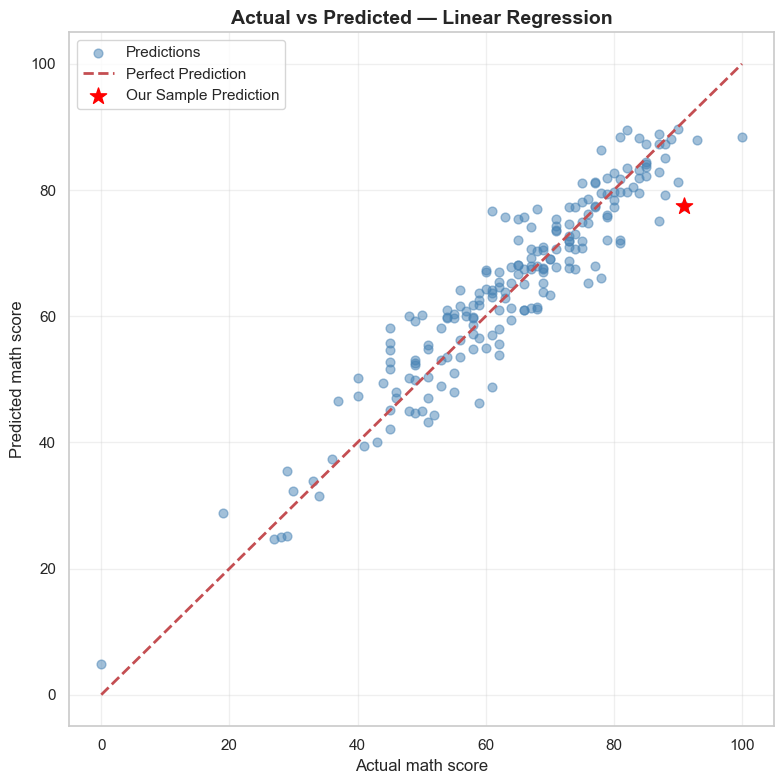


=== Final Summary ===
Best Model:  Linear Regression
Test R²:     0.8815
Test RMSE:   5.3695


In [45]:
# Visualization: Actual vs Predicted on full test set
y_pred_best = loaded_model.predict(X_test_arr)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=40, label='Predictions')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.scatter(y_test[sample_index], predicted_score, color='red', s=150, zorder=5,
            marker='*', label='Our Sample Prediction')
plt.xlabel('Actual math score', fontsize=12)
plt.ylabel('Predicted math score', fontsize=12)
plt.title(f'Actual vs Predicted — {best_idx}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n=== Final Summary ===')
print(f'Best Model:  {best_idx}')
print(f'Test R²:     {r2_score(y_test, y_pred_best):.4f}')
print(f'Test RMSE:   {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')